# AEP Hourly Energy Load Forecasting with LSTM

Predicting hourly energy consumption using a Long Short-Term Memory (LSTM) neural network 
trained on 13 years of AEP (American Electric Power) hourly load data. This project 
demonstrates how deep learning can model complex temporal patterns in energy systems 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

## 1. Data Loading & Exploration

The dataset contains 121,273 hourly energy consumption readings (in megawatts) from 
AEP spanning October 2004 to August 2018. No missing values were found.

In [4]:
df = pd.read_csv('data/AEP_hourly.csv', sep=',')

print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(121273, 2)
              Datetime   AEP_MW
0  2004-12-31 01:00:00  13478.0
1  2004-12-31 02:00:00  12865.0
2  2004-12-31 03:00:00  12577.0
3  2004-12-31 04:00:00  12517.0
4  2004-12-31 05:00:00  12670.0
Datetime     object
AEP_MW      float64
dtype: object
Datetime    0
AEP_MW      0
dtype: int64


In [5]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')
df = df.sort_index()
print(df.head())
print(df.index.min(), 'to', df.index.max())

                      AEP_MW
Datetime                    
2004-10-01 01:00:00  12379.0
2004-10-01 02:00:00  11935.0
2004-10-01 03:00:00  11692.0
2004-10-01 04:00:00  11597.0
2004-10-01 05:00:00  11681.0
2004-10-01 01:00:00 to 2018-08-03 00:00:00


## 2. Exploratory Data Analysis

Plotting the full time series reveals strong seasonal patterns with peaks in summer and 
winter, troughs in spring and fall, as well as daily cycles. These repeating structures 
make this an ideal candidate for sequence modeling.

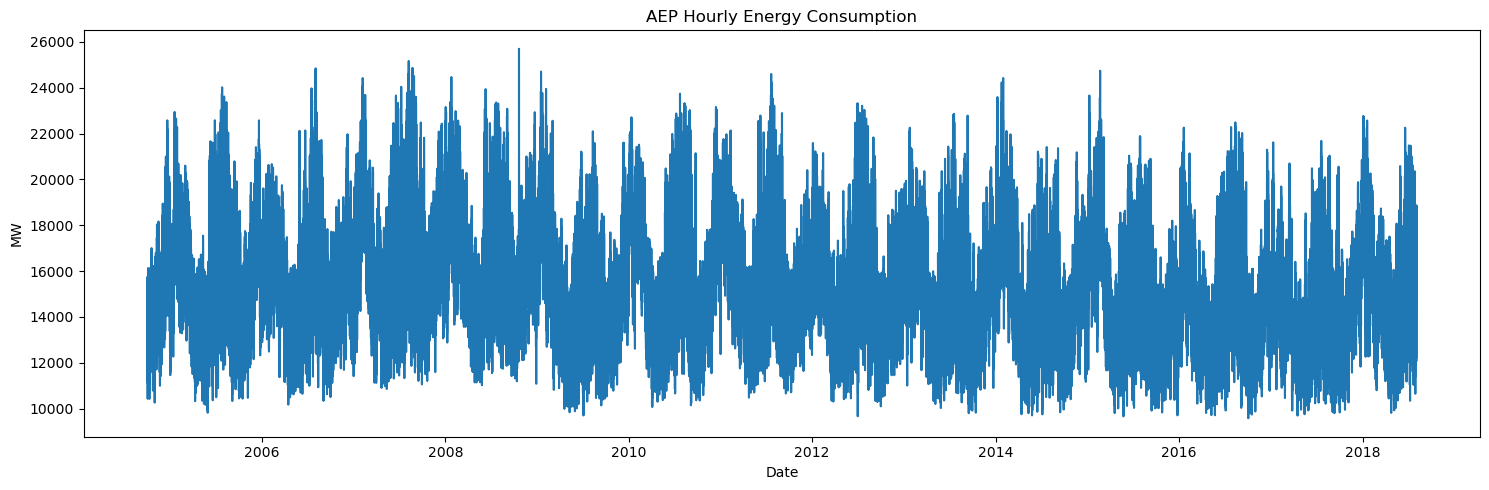

In [6]:
plt.figure(figsize=(15, 5))
plt.plot(df['AEP_MW'])
plt.title('AEP Hourly Energy Consumption')
plt.xlabel('Date')
plt.ylabel('MW')
plt.tight_layout()plt.figure(figsize=(15, 5))
plt.plot(df['AEP_MW'])
plt.title('AEP Hourly Energy Consumption')
plt.xlabel('Date')
plt.ylabel('MW')
plt.tight_layout()
plt.show()
plt.show()

## 3. Preprocessing

Data is normalized to [0, 1] using MinMaxScaler to improve LSTM training stability. 
Sequences of 24 timesteps (past 24 hours) are created as input windows to predict 
the next hour's consumption.

In [7]:
# Normalize
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[['AEP_MW']])

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 24  # use past 24 hours to predict next hour
X, y = create_sequences(scaled, SEQ_LENGTH)
print(X.shape, y.shape)

(121249, 24, 1) (121249, 1)


## 4. Train/Test Split

80% of the data is used for training (~ 97,000 samples), and 20% for testing (~ 24,000 
samples). The split preserves temporal order by not shuffling to prevent data leakage.



In [8]:
# 80/20 split
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Convert to tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

# DataLoaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: torch.Size([96999, 24, 1]), Test: torch.Size([24250, 24, 1])


## 5. LSTM Model Architecture

A two-layer LSTM with 64 hidden units and 0.2 dropout, followed by a fully connected 
output layer. The model takes a 24-hour window as input and predicts the next hour's 
energy consumption.

In [11]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## 6. Training

Trained for 30 epochs using Adam optimizer and MSE loss. Loss decreased steadily from 
0.006 to 0.000140, indicating strong convergence.

In [15]:
EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    avg_loss = train_loss / len(train_loader)
    print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.6f}')

Epoch 1/30, Loss: 0.000246
Epoch 2/30, Loss: 0.000233
Epoch 3/30, Loss: 0.000221
Epoch 4/30, Loss: 0.000217
Epoch 5/30, Loss: 0.000209
Epoch 6/30, Loss: 0.000204
Epoch 7/30, Loss: 0.000197
Epoch 8/30, Loss: 0.000194
Epoch 9/30, Loss: 0.000188
Epoch 10/30, Loss: 0.000184
Epoch 11/30, Loss: 0.000179
Epoch 12/30, Loss: 0.000178
Epoch 13/30, Loss: 0.000175
Epoch 14/30, Loss: 0.000172
Epoch 15/30, Loss: 0.000169
Epoch 16/30, Loss: 0.000166
Epoch 17/30, Loss: 0.000165
Epoch 18/30, Loss: 0.000158
Epoch 19/30, Loss: 0.000158
Epoch 20/30, Loss: 0.000157
Epoch 21/30, Loss: 0.000154
Epoch 22/30, Loss: 0.000153
Epoch 23/30, Loss: 0.000155
Epoch 24/30, Loss: 0.000152
Epoch 25/30, Loss: 0.000149
Epoch 26/30, Loss: 0.000150
Epoch 27/30, Loss: 0.000147
Epoch 28/30, Loss: 0.000146
Epoch 29/30, Loss: 0.000144
Epoch 30/30, Loss: 0.000140


## 7. Evaluation

Model predictions are inverse-transformed back to megawatts and evaluated against 
actuals using RMSE and MAE.

RMSE: 222.44 MW
MAE: 163.37 MW


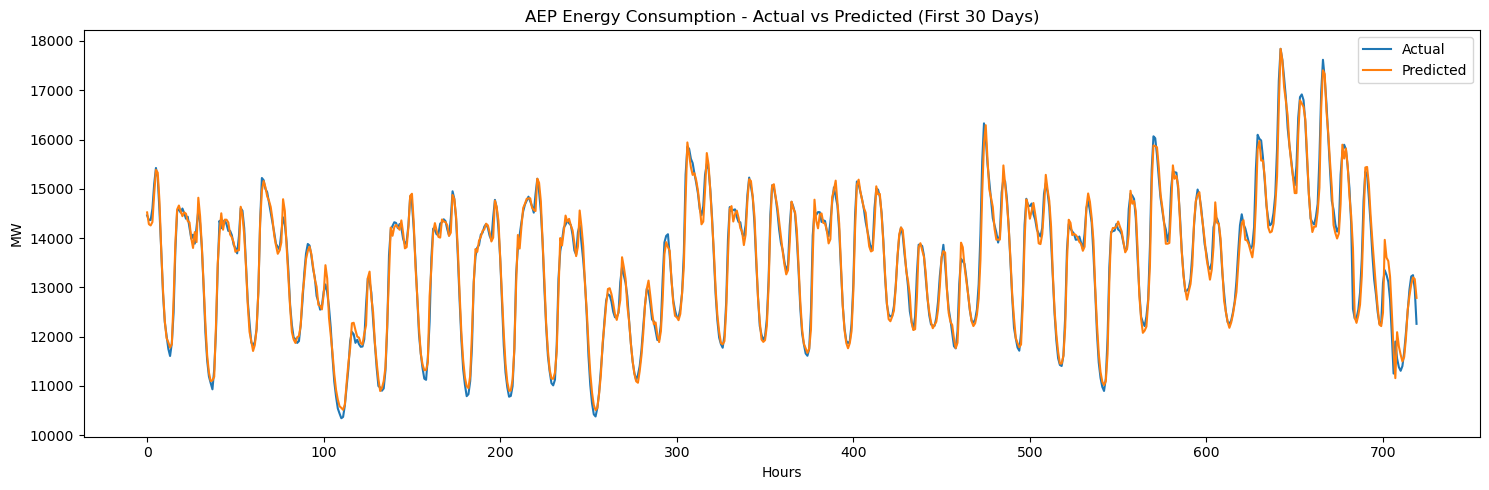

In [17]:
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        output = model(X_batch)
        predictions.append(output.numpy())
        actuals.append(y_batch.numpy())

predictions = np.concatenate(predictions, axis=0)
actuals = np.concatenate(actuals, axis=0)

# Inverse transform
predictions = scaler.inverse_transform(predictions)
actuals = scaler.inverse_transform(actuals)

# Metrics
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = mean_absolute_error(actuals, predictions)
print(f'RMSE: {rmse:.2f} MW')
print(f'MAE: {mae:.2f} MW')

# Plot
plt.figure(figsize=(15, 5))
plt.plot(actuals[:720], label='Actual')
plt.plot(predictions[:720], label='Predicted')
plt.title('AEP Energy Consumption - Actual vs Predicted (First 30 Days)')
plt.xlabel('Hours')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Baseline Comparison

A naive persistence model (predicting next hour = current hour) serves as the baseline. 
The LSTM reduces RMSE by 57% and MAE by 60% compared to this baseline, confirming 
that the model has learned meaningful temporal structure beyond simple autocorrelation.

In [18]:
torch.save(model.state_dict(), 'lstm_aep_model.pth')

# Naive baseline: predict next hour = current hour (persistence model)
baseline_preds = actuals[:-1]
baseline_actuals = actuals[1:]

baseline_rmse = np.sqrt(mean_squared_error(baseline_actuals, baseline_preds))
baseline_mae = mean_absolute_error(baseline_actuals, baseline_preds)

print(f'Baseline RMSE: {baseline_rmse:.2f} MW')
print(f'Baseline MAE: {baseline_mae:.2f} MW')
print(f'LSTM RMSE: {222.44:.2f} MW')
print(f'LSTM MAE: {163.37:.2f} MW')

Baseline RMSE: 525.58 MW
Baseline MAE: 407.64 MW
LSTM RMSE: 222.44 MW
LSTM MAE: 163.37 MW


## 9. Conclusion

The LSTM achieved RMSE of 222.44 MW and MAE of 163.37 MW on unseen test data, 
representing roughly 1.4% average error relative to mean consumption (~15,500 MW). 
The model successfully captures both daily and seasonal patterns in energy load, 
demonstrating the viability of deep learning for energy forecasting in power systems 
and data center load management applications.